# Lire le dataset issu de l'étape cleaning

In [36]:
# Librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Charger le dataset après cleaning
df = pd.read_csv('../data/processed/step2_cleaning.csv')

# Vérification rapide
print("Shape du dataset :", df.shape)
df.head()


Shape du dataset : (4372, 54)


,CustomerID,Recency,Frequency,MonetaryTotal,MonetaryAvg,MonetaryStd,MonetaryMin,MonetaryMax,TotalQuantity,AvgQuantityPerTransaction,...,ProductDiversity,Gender,AccountStatus,Country,Churn,MonetaryTotal_log,RegYear,RegMonth,RegDay,RegWeekday
0,17850,302,35,5288.63,16.950737,13.603662,-30.60,107.25,1693,5.426282,...,Explorateur,Unknown,Active,United Kingdom,1,8.573504,2010,7,17,5
1,13047,32,18,3079.10,15.709694,11.684769,-15.00,68.00,1355,6.913265,...,Explorateur,M,Active,United Kingdom,0,8.032717,2010,4,10,5
2,12583,3,18,7187.34,28.634821,23.150132,-60.84,132.80,5009,19.956175,...,Explorateur,Unknown,Active,France,0,8.880216,2009,9,12,5
3,13748,96,5,948.25,33.866071,42.953119,9.36,204.00,439,15.678571,...,Explorateur,Unknown,Active,United Kingdom,1,6.855672,2010,1,28,3
4,15100,330,6,635.10,105.850000,215.986263,-131.40,350.40,58,9.666667,...,Spécialisé,M,Active,United Kingdom,1,6.455356,2009,10,12,0


1. Analyse rapide des colonnes

In [37]:
# Colonnes numériques
num_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
print("Colonnes numériques :", num_cols)

# Colonnes catégorielles
cat_cols = df.select_dtypes(include=['object','category']).columns.tolist()
print("Colonnes catégorielles :", cat_cols)


Colonnes numériques : ['CustomerID', 'Recency', 'Frequency', 'MonetaryTotal', 'MonetaryAvg', 'MonetaryStd', 'MonetaryMin', 'MonetaryMax', 'TotalQuantity', 'AvgQuantityPerTransaction', 'MinQuantity', 'MaxQuantity', 'CustomerTenureDays', 'FirstPurchaseDaysAgo', 'PreferredDayOfWeek', 'PreferredHour', 'PreferredMonth', 'WeekendPurchaseRatio', 'AvgDaysBetweenPurchases', 'UniqueProducts', 'UniqueDescriptions', 'AvgProductsPerTransaction', 'UniqueCountries', 'NegativeQuantityCount', 'ZeroPriceCount', 'CancelledTransactions', 'ReturnRatio', 'TotalTransactions', 'UniqueInvoices', 'AvgLinesPerInvoice', 'Age', 'SupportTicketsCount', 'SatisfactionScore', 'Churn', 'MonetaryTotal_log', 'RegYear', 'RegMonth', 'RegDay', 'RegWeekday']
Colonnes catégorielles : ['RFMSegment', 'AgeCategory', 'SpendingCategory', 'CustomerType', 'FavoriteSeason', 'PreferredTimeOfDay', 'Region', 'LoyaltyLevel', 'ChurnRiskCategory', 'WeekendPreference', 'BasketSizeCategory', 'ProductDiversity', 'Gender', 'AccountStatus', 'Cou

C:\Users\chaie\AppData\Local\Temp\ipykernel_15996\4015174587.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object','category']).columns.tolist()


2. Création de nouvelles features numériques

# 1. Features basiques

1.1 Dépense par jour

In [38]:
df['MonetaryPerDay'] = df['MonetaryTotal'] / (df['Recency'] + 1)
#client dépense combien par jour => client dépense combien par jour

1.2 Panier moyen amélioré

In [39]:
df['AvgBasketValue'] = df['MonetaryTotal'] / (df['Frequency'] + 1)
#taille moyenne du panier => client VIP vs petit client

In [40]:
df['PurchaseIntensity'] = df['Frequency'] / (df['CustomerTenureDays'] + 1)


1.3 Intensité d’achat

In [41]:
df['PurchaseIntensity'] = df['Frequency'] / (df['CustomerTenureDays'] + 1)
#fréquence d’achat dans le temps => client fidèle ou pas

1.4 Ratio récence / ancienneté

In [42]:
df['TenureRatio'] = df['Recency'] / (df['CustomerTenureDays'] + 1)
#compare ancienneté vs activité récente => détecter churn 

In [43]:
df[['MonetaryTotal', 'Recency', 'MonetaryPerDay',
    'Frequency', 'AvgBasketValue',
    'PurchaseIntensity', 'TenureRatio']].head(10)

,MonetaryTotal,Recency,MonetaryPerDay,Frequency,AvgBasketValue,PurchaseIntensity,TenureRatio
0,5288.63,302,17.454224,35,146.906389,0.486111,4.194444
1,3079.10,32,93.306061,18,162.057895,0.052478,0.093294
2,7187.34,3,1796.835000,18,378.281053,0.048518,0.008086
3,948.25,96,9.775773,5,158.041667,0.017921,0.344086
4,635.10,330,1.918731,6,90.728571,0.136364,7.500000
5,4596.51,26,170.241111,20,218.881429,0.057307,0.074499
6,5107.38,8,567.486667,27,182.406429,0.073569,0.021798
7,4627.62,16,272.212941,15,289.226250,0.041899,0.044693
8,59419.34,1,29709.670000,118,499.322185,0.315508,0.002674
9,7711.38,3,1927.845000,86,88.636552,0.231183,0.008065


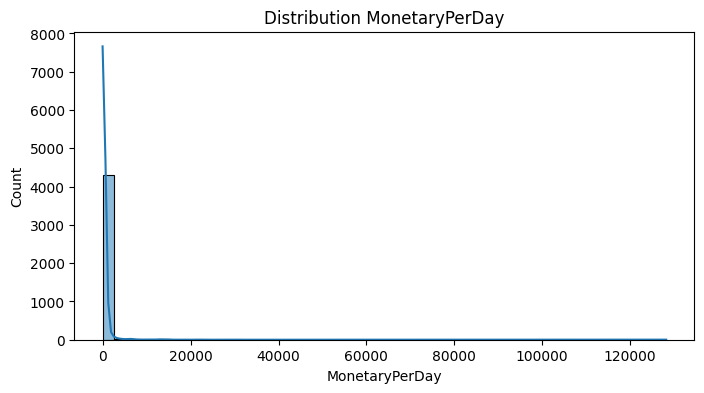

In [44]:
plt.figure(figsize=(8,4))
sns.histplot(df['MonetaryPerDay'], bins=50, kde=True)
plt.title("Distribution MonetaryPerDay")
plt.show()

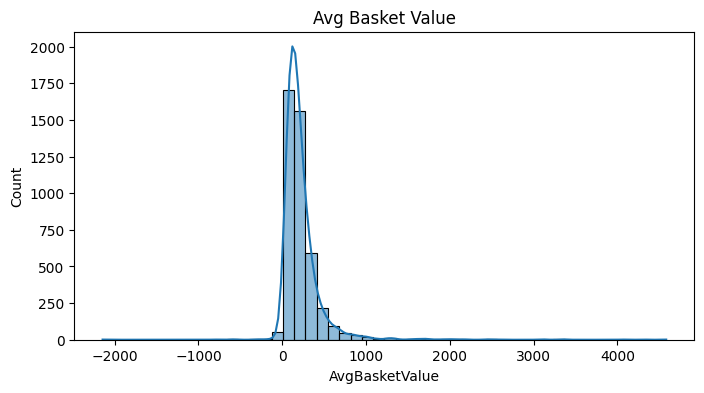

In [45]:
plt.figure(figsize=(8,4))
sns.histplot(df['AvgBasketValue'], bins=50, kde=True)
plt.title("Avg Basket Value")
plt.show()


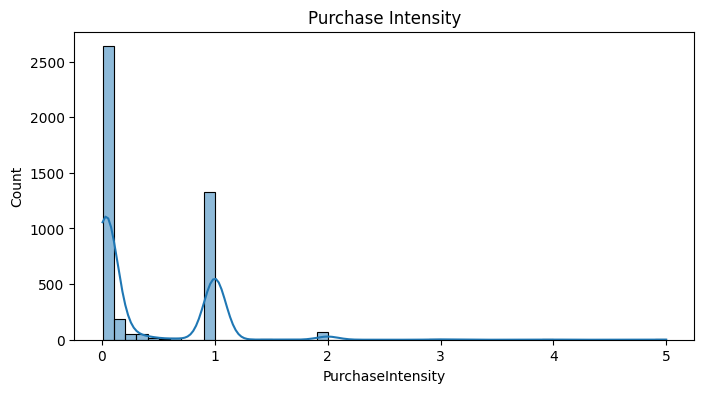

In [46]:
plt.figure(figsize=(8,4))
sns.histplot(df['PurchaseIntensity'], bins=50, kde=True)
plt.title("Purchase Intensity")
plt.show()


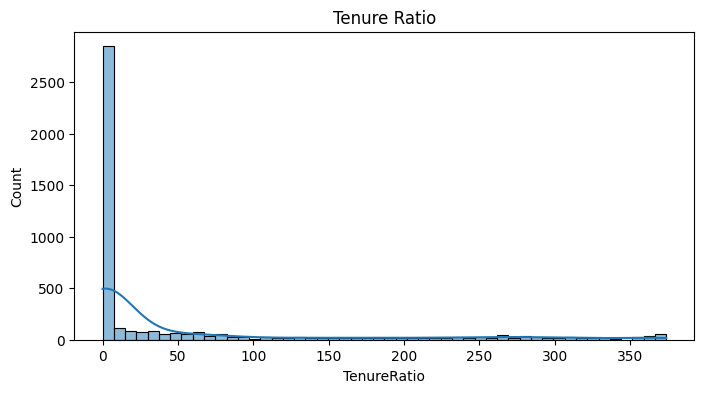

In [47]:
plt.figure(figsize=(8,4))
sns.histplot(df['TenureRatio'], bins=50, kde=True)
plt.title("Tenure Ratio")
plt.show()
#valeur élevée = client inactif ⚠️

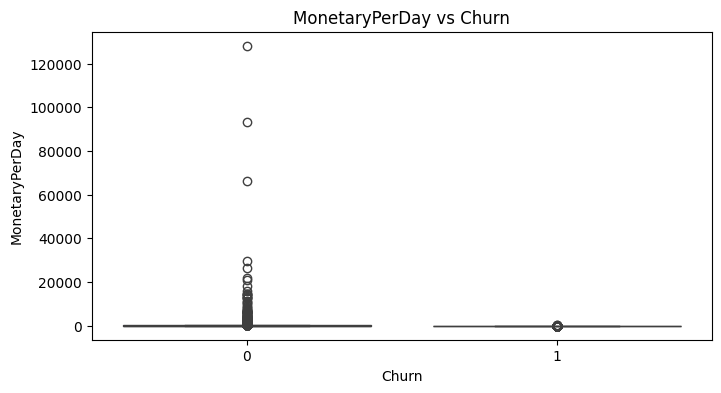

In [48]:
plt.figure(figsize=(8,4))
sns.boxplot(x='Churn', y='MonetaryPerDay', data=df)
plt.title("MonetaryPerDay vs Churn")
plt.show()


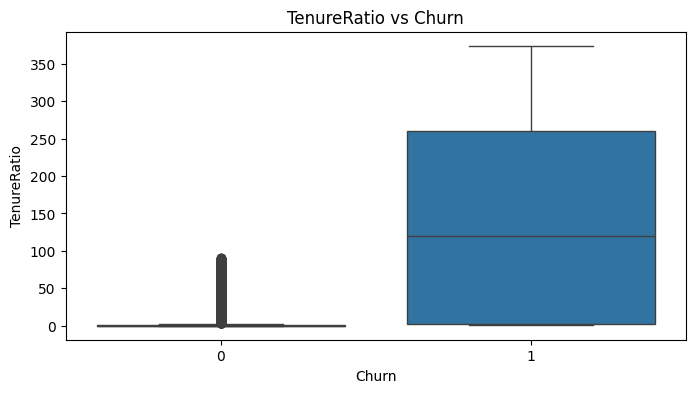

In [49]:
plt.figure(figsize=(8,4))
sns.boxplot(x='Churn', y='TenureRatio', data=df)
plt.title("TenureRatio vs Churn")
plt.show()


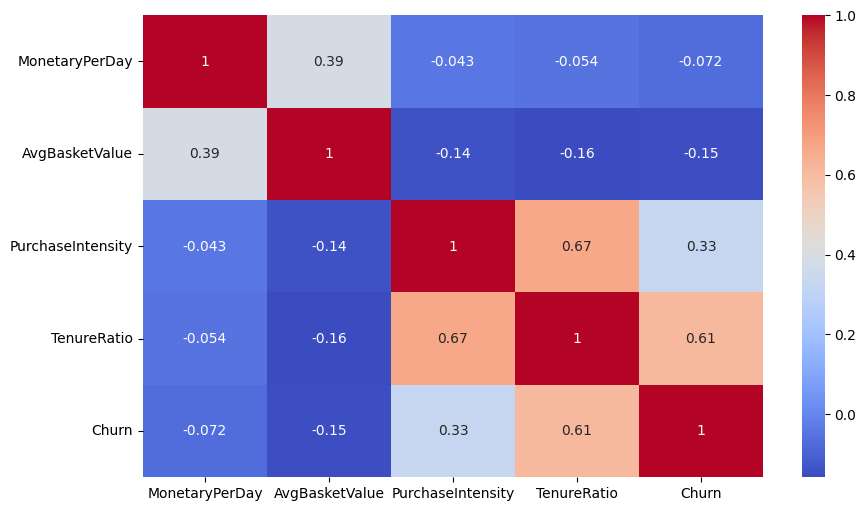

In [50]:
plt.figure(figsize=(10,6))
sns.heatmap(df[['MonetaryPerDay','AvgBasketValue',
                'PurchaseIntensity','TenureRatio','Churn']].corr(),
            annot=True, cmap='coolwarm')
plt.show()


# 2. Features comportementales

2.1 Diversité produits

In [51]:
df['ProductDiversityRatio'] = df['UniqueProducts'] / (df['Frequency'] + 1)
#diversité des produits achetés => client qui achète toujours les mêmes produits vs client qui varie

2.2 Impact des retours

In [52]:
df['ReturnImpact'] = df['ReturnRatio'] * df['MonetaryTotal']
#impact des retours sur la valeur du client => client qui fait beaucoup de retours et dépense beaucoup = client à risque

2.3 Engagement client

In [53]:
df['EngagementScore'] = (df['Frequency']+df['TotalQuantity']+df['UniqueProducts']) 
#score d’engagement global => client très actif vs client peu actif
df['EngagementScoreNormalized'] = df['EngagementScore'] / df['CustomerTenureDays']
#normaliser par ancienneté pour éviter biais

2.4 Score client

In [54]:
df['CustomerScore'] = (df['Frequency']*0.4 + df['MonetaryTotal']*0.4 + df['Recency']*0.2)
#score global pondéré => client à fort potentiel vs client à faible potentiel
df['CustomerScoreNormalized'] = df['CustomerScore'] / df['CustomerTenureDays']
#normaliser par ancienneté pour éviter biais

In [56]:
df.head(10)

,CustomerID,Recency,Frequency,MonetaryTotal,MonetaryAvg,MonetaryStd,MonetaryMin,MonetaryMax,TotalQuantity,AvgQuantityPerTransaction,...,MonetaryPerDay,AvgBasketValue,PurchaseIntensity,TenureRatio,ProductDiversityRatio,ReturnImpact,EngagementScore,EngagementScoreNormalized,CustomerScore,CustomerScoreNormalized
0,17850,302,35,5288.63,16.950737,13.603662,-30.60,107.25,1693,5.426282,...,17.454224,146.906389,0.486111,4.194444,0.666667,254.261058,1752,24.676056,2189.852,30.842986
1,13047,32,18,3079.10,15.709694,11.684769,-15.00,68.00,1355,6.913265,...,93.306061,162.057895,0.052478,0.093294,5.578947,377.032653,1479,4.324561,1245.240,3.641053
2,12583,3,18,7187.34,28.634821,23.150132,-60.84,132.80,5009,19.956175,...,1796.835000,378.281053,0.048518,0.008086,6.052632,114.539283,5142,13.897297,2882.736,7.791178
3,13748,96,5,948.25,33.866071,42.953119,9.36,204.00,439,15.678571,...,9.775773,158.041667,0.017921,0.344086,4.000000,0.000000,468,1.683453,400.500,1.440647
4,15100,330,6,635.10,105.850000,215.986263,-131.40,350.40,58,9.666667,...,1.918731,90.728571,0.136364,7.500000,0.142857,317.550000,65,1.511628,322.440,7.498605
5,15291,26,20,4596.51,42.169817,49.090861,-35.49,243.36,2074,19.027523,...,170.241111,218.881429,0.057307,0.074499,3.000000,253.018899,2157,6.198276,1851.804,5.321276
6,14688,8,27,5107.38,14.226685,23.644470,-72.15,153.00,3222,8.974930,...,567.486667,182.406429,0.073569,0.021798,5.285714,455.253928,3397,9.281421,2055.352,5.615716
7,17809,16,15,4627.62,72.306562,142.206440,-717.23,425.00,2015,31.484375,...,272.212941,289.226250,0.041899,0.044693,2.937500,216.919688,2077,5.817927,1860.248,5.210779
8,15311,1,118,59419.34,23.853609,46.625077,-275.00,408.00,37720,15.142513,...,29709.670000,499.322185,0.315508,0.002674,4.798319,2671.604207,38409,102.973190,23815.136,63.847550
9,14527,3,86,7711.38,7.627478,9.759291,-80.00,87.60,2049,2.026706,...,1927.845000,88.636552,0.231183,0.008065,3.804598,297.471632,2466,6.646900,3119.552,8.408496
